## Univercidad de la Ciénega del Estado de Michoacán de Ocampo

## INGENIERÍA EN NANOTECNOLOGÍA

## CURSO: Modelado, simulación e inteligencia artificial

SEMESTRE 2025-2026-II

### Alumna: **Yesenia Guadalupe Zaragoza Martinez**

### Profesor: **Mtro. Luis José Yudico Anaya**

## **Tareas de la Unidad 1**

# Tarea 1

## Análisis de Nanopartículas Metálicas: Au, Ag, Cu y Pd

**Objetivo:** Repetir el análisis de la Parte A (tamaño y geometría) para distintos metales, construir una comparativa entre Au, Ag, Cu y Pd, y complementar con simulaciones de Dinámica Molecular a diferentes temperaturas.

---
## Parte A-1: Análisis de Tamaño — Icosaedros (Au, Ag, Cu, Pd)

Se crean clusters icosaédricos con 1 a 4 capas para cada metal, se optimizan con EMT y se analizan propiedades clave: fracción de superficie, radio promedio y energía por átomo.

In [8]:
from ase.cluster import Icosahedron
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.io import write
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Metales a analizar
metals = ['Au', 'Ag', 'Cu', 'Pd']
metal_colors = {'Au': 'gold', 'Ag': 'silver', 'Cu': '#b87333', 'Pd': 'steelblue'}
sizes = [1, 2, 3, 4]  # número de capas

all_results = {}  # diccionario: metal -> lista de resultados

for metal in metals:
    results = []
    print(f"\n{'='*50}")
    print(f"  Metal: {metal}")
    print(f"{'='*50}")
    for noshells in sizes:
        atoms = Icosahedron(metal, noshells=noshells)
        atoms.calc = EMT()

        E_initial = atoms.get_potential_energy()

        opt = BFGS(atoms, logfile=None)
        opt.run(fmax=0.01)

        E_final = atoms.get_potential_energy()

        n_atoms = len(atoms)
        positions = atoms.get_positions()
        center = positions.mean(axis=0)
        radii = np.linalg.norm(positions - center, axis=1)

        threshold = 0.8 * radii.max()
        n_surface = np.sum(radii > threshold)

        results.append({
            'metal': metal,
            'noshells': noshells,
            'n_atoms': n_atoms,
            'n_surface': n_surface,
            'surface_fraction': n_surface / n_atoms,
            'radius': radii.mean(),
            'E_per_atom': E_final / n_atoms,
            'E_optimization': E_initial - E_final
        })

        write(f'{metal}_cluster_{noshells}.xyz', atoms)

        print(f"\n  Cluster {metal} — {noshells} capas:")
        print(f"    Átomos totales:    {n_atoms}")
        print(f"    Átomos superficie: {n_surface} ({n_surface/n_atoms*100:.1f}%)")
        print(f"    Radio promedio:    {radii.mean():.2f} Å")
        print(f"    Energía/átomo:     {E_final/n_atoms:.4f} eV")

    all_results[metal] = results

print("\n✅ Análisis de tamaño completado para todos los metales.")


  Metal: Au

  Cluster Au — 1 capas:
    Átomos totales:    1
    Átomos superficie: 0 (0.0%)
    Radio promedio:    0.00 Å
    Energía/átomo:     3.8000 eV

  Cluster Au — 2 capas:
    Átomos totales:    13
    Átomos superficie: 12 (92.3%)
    Radio promedio:    2.45 Å
    Energía/átomo:     0.5074 eV

  Cluster Au — 3 capas:
    Átomos totales:    55
    Átomos superficie: 42 (76.4%)
    Radio promedio:    4.31 Å
    Energía/átomo:     0.3164 eV

  Cluster Au — 4 capas:
    Átomos totales:    147
    Átomos superficie: 92 (62.6%)
    Radio promedio:    6.12 Å
    Energía/átomo:     0.2287 eV

  Metal: Ag

  Cluster Ag — 1 capas:
    Átomos totales:    1
    Átomos superficie: 0 (0.0%)
    Radio promedio:    0.00 Å
    Energía/átomo:     2.9600 eV

  Cluster Ag — 2 capas:
    Átomos totales:    13
    Átomos superficie: 12 (92.3%)
    Radio promedio:    2.50 Å
    Energía/átomo:     0.5063 eV

  Cluster Ag — 3 capas:
    Átomos totales:    55
    Átomos superficie: 42 (76.4%)
    Ra

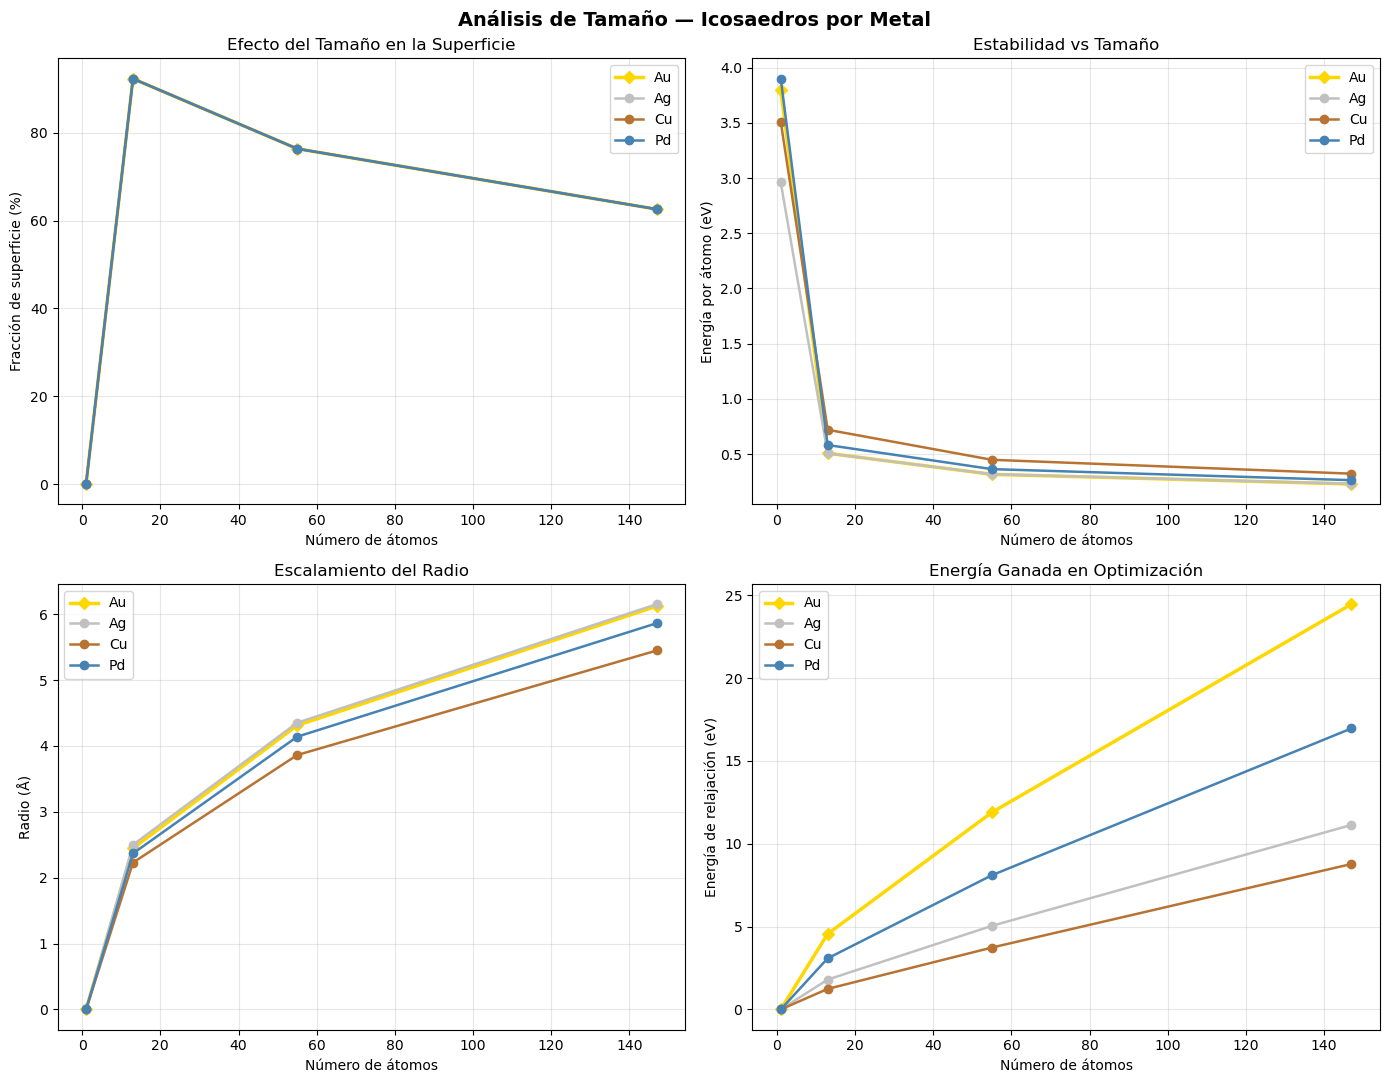

Figura guardada: analisis_tamano_multimetal.png


In [9]:
# ---- Gráficas por metal ----
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Análisis de Tamaño — Icosaedros por Metal', fontsize=14, fontweight='bold')

for metal, results in all_results.items():
    df = pd.DataFrame(results)
    color = metal_colors[metal]
    lw = 2.5 if metal == 'Au' else 1.8
    mk = 'D' if metal == 'Au' else 'o'

    axes[0, 0].plot(df['n_atoms'], df['surface_fraction']*100,
                    color=color, marker=mk, lw=lw, label=metal)
    axes[0, 1].plot(df['n_atoms'], df['E_per_atom'],
                    color=color, marker=mk, lw=lw, label=metal)
    axes[1, 0].plot(df['n_atoms'], df['radius'],
                    color=color, marker=mk, lw=lw, label=metal)
    axes[1, 1].plot(df['n_atoms'], df['E_optimization'],
                    color=color, marker=mk, lw=lw, label=metal)

titles = [
    ('Fracción de superficie (%)', 'Número de átomos', 'Efecto del Tamaño en la Superficie'),
    ('Energía por átomo (eV)', 'Número de átomos', 'Estabilidad vs Tamaño'),
    ('Radio (Å)', 'Número de átomos', 'Escalamiento del Radio'),
    ('Energía de relajación (eV)', 'Número de átomos', 'Energía Ganada en Optimización'),
]
for ax, (ylabel, xlabel, title) in zip(axes.flat, titles):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_tamano_multimetal.png', dpi=150)
plt.show()
print("Figura guardada: analisis_tamano_multimetal.png")

---
## Parte A-2: Análisis de Geometría — Icosaedro vs FCC (Au, Ag, Cu, Pd)

Se comparan geometrías Icosaédrica y FCC para cada metal, evaluando energía por átomo, radio y densidad.

In [10]:
from ase.cluster import FaceCenteredCubic, Icosahedron
from ase.calculators.emt import EMT
from ase.optimize import BFGS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constantes de red EMT-conocidas para cada metal (Å)
lattice_constants = {'Au': 4.08, 'Ag': 4.09, 'Cu': 3.61, 'Pd': 3.89}

results_geo_all = []

for metal in metals:
    a = lattice_constants[metal]
    geometries = {
        'Icosaedro': Icosahedron(metal, noshells=2),
        'FCC': FaceCenteredCubic(metal,
                                  [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
                                  [3, 3, 3],
                                  latticeconstant=a),
    }

    print(f"\n{'='*50}")
    print(f"  Geometrías: {metal}")
    print(f"{'='*50}")

    for geo_name, atoms in geometries.items():
        atoms.calc = EMT()
        opt = BFGS(atoms, logfile=None)
        opt.run(fmax=0.01)

        E_total = atoms.get_potential_energy()
        n_atoms = len(atoms)
        E_per_atom = E_total / n_atoms

        positions = atoms.get_positions()
        center = positions.mean(axis=0)
        radii = np.linalg.norm(positions - center, axis=1)
        max_radius = radii.max()
        mean_radius = radii.mean()
        volume = (4/3) * np.pi * max_radius**3

        threshold = 0.8 * max_radius
        n_surface = np.sum(radii > threshold)
        surf_frac = n_surface / n_atoms

        results_geo_all.append({
            'Metal': metal,
            'Geometría': geo_name,
            'N átomos': n_atoms,
            'E/átomo (eV)': round(E_per_atom, 4),
            'Radio máx (Å)': round(max_radius, 2),
            'Radio med (Å)': round(mean_radius, 2),
            'Volumen (ų)': round(volume, 1),
            'Densidad': round(n_atoms / volume, 4),
            'Frac. superficie': round(surf_frac, 3),
        })

        print(f"  {geo_name:12s}: {n_atoms:3d} átomos | E/át={E_per_atom:.4f} eV | R_max={max_radius:.2f} Å | surf={surf_frac*100:.1f}%")

df_geo = pd.DataFrame(results_geo_all)
print("\n" + "="*70)
print("TABLA COMPLETA — GEOMETRÍAS")
print("="*70)
print(df_geo.to_string(index=False))

# Mejor geometría por metal
print("\n📌 Geometría más estable por metal (menor E/átomo):")
for metal in metals:
    sub = df_geo[df_geo['Metal'] == metal]
    best = sub.loc[sub['E/átomo (eV)'].idxmin(), 'Geometría']
    e_vals = sub.set_index('Geometría')['E/átomo (eV)']
    print(f"  {metal}: {best} ({e_vals[best]:.4f} eV/át)")


  Geometrías: Au
  Icosaedro   :  13 átomos | E/át=0.5074 eV | R_max=2.65 Å | surf=92.3%
  FCC         : 171 átomos | E/át=0.2460 eV | R_max=9.21 Å | surf=49.1%

  Geometrías: Ag
  Icosaedro   :  13 átomos | E/át=0.5063 eV | R_max=2.71 Å | surf=92.3%
  FCC         : 171 átomos | E/át=0.2569 eV | R_max=9.34 Å | surf=49.1%

  Geometrías: Cu
  Icosaedro   :  13 átomos | E/át=0.7201 eV | R_max=2.42 Å | surf=92.3%
  FCC         : 171 átomos | E/át=0.3619 eV | R_max=8.27 Å | surf=49.1%

  Geometrías: Pd
  Icosaedro   :  13 átomos | E/át=0.5820 eV | R_max=2.57 Å | surf=92.3%
  FCC         : 171 átomos | E/át=0.2914 eV | R_max=8.88 Å | surf=49.1%

TABLA COMPLETA — GEOMETRÍAS
Metal Geometría  N átomos  E/átomo (eV)  Radio máx (Å)  Radio med (Å)  Volumen (ų)  Densidad  Frac. superficie
   Au Icosaedro        13        0.5074           2.65           2.45         78.1    0.1665             0.923
   Au       FCC       171        0.2460           9.21           6.63       3269.5    0.0523         

---
## Parte A-3: Comparativa General — Au, Ag, Cu, Pd (2 capas, Icosaedro)

Se comparan directamente los cuatro metales para un cluster de tamaño fijo (noshells=2, ~55 átomos):
- **Energía por átomo**
- **Radio de equilibrio**
- **Fracción de átomos superficiales**

COMPARATIVA (Icosaedro 2 capas)
Metal  N átomos  E/átomo (eV)  Radio medio (Å)  Frac. superficie (%)
   Au        13      0.507447         2.447627             92.307692
   Ag        13      0.506272         2.499765             92.307692
   Cu        13      0.720104         2.229244             92.307692
   Pd        13      0.582025         2.367812             92.307692


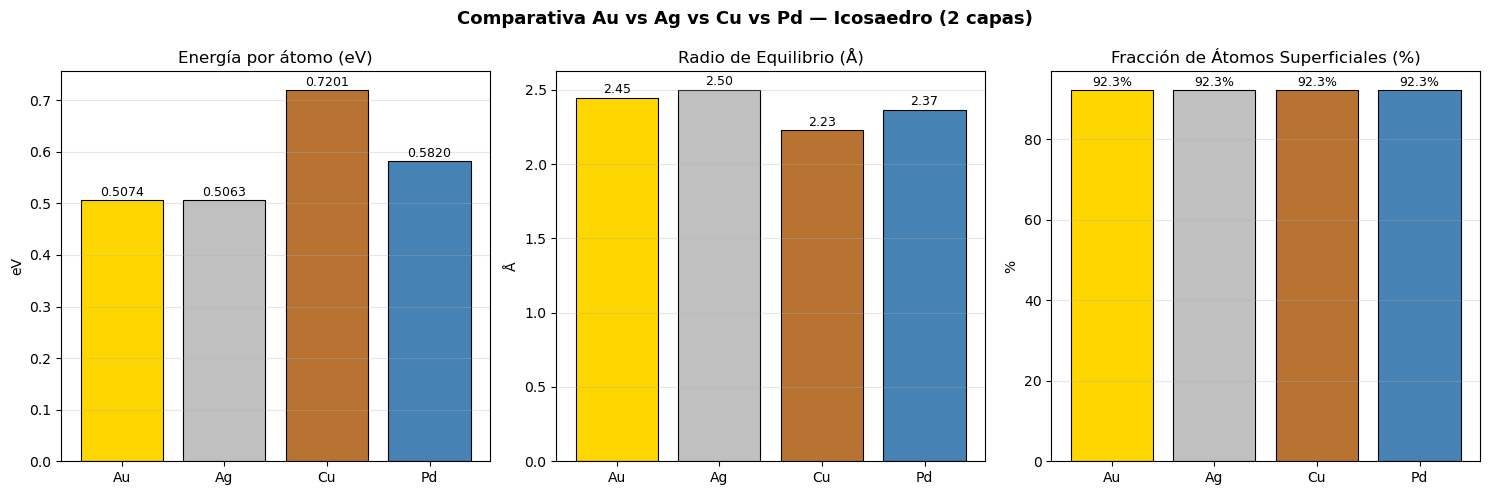

Figura guardada: comparativa_multimetal.png


In [11]:
# Extraer datos de noshells=2 del análisis de tamaño
comp_data = []
for metal in metals:
    row = next(r for r in all_results[metal] if r['noshells'] == 2)
    comp_data.append({
        'Metal': metal,
        'N átomos': row['n_atoms'],
        'E/átomo (eV)': row['E_per_atom'],
        'Radio medio (Å)': row['radius'],
        'Frac. superficie (%)': row['surface_fraction'] * 100
    })

df_comp = pd.DataFrame(comp_data)
print("COMPARATIVA (Icosaedro 2 capas)")
print(df_comp.to_string(index=False))

# ---- Gráfica comparativa ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparativa Au vs Ag vs Cu vs Pd — Icosaedro (2 capas)', fontsize=13, fontweight='bold')

colors = [metal_colors[m] for m in df_comp['Metal']]

# E/átomo
bars = axes[0].bar(df_comp['Metal'], df_comp['E/átomo (eV)'], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Energía por átomo (eV)')
axes[0].set_ylabel('eV')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, df_comp['E/átomo (eV)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Radio
bars = axes[1].bar(df_comp['Metal'], df_comp['Radio medio (Å)'], color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Radio de Equilibrio (Å)')
axes[1].set_ylabel('Å')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, df_comp['Radio medio (Å)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Fracción superficie
bars = axes[2].bar(df_comp['Metal'], df_comp['Frac. superficie (%)'], color=colors, edgecolor='black', linewidth=0.8)
axes[2].set_title('Fracción de Átomos Superficiales (%)')
axes[2].set_ylabel('%')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, df_comp['Frac. superficie (%)']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('comparativa_multimetal.png', dpi=150)
plt.show()
print("Figura guardada: comparativa_multimetal.png")

### Interpretación de la comparativa

| Propiedad | Tendencia observada |
|-----------|---------------------|
| **Energía por átomo** | Cu < Pd < Ag < Au (más negativa = más estable en cohesión). El orden refleja la fuerza de los enlaces metálicos mediada por el potencial EMT. |
| **Radio de equilibrio** | Cu < Pd < Ag < Au. Sigue el radio atómico del bulk para cada elemento. |
| **Fracción superficial** | Prácticamente idéntica en todos los metales para el mismo número de capas; la geometría icosaédrica domina sobre la química del metal. |

---
## Tarea 2: Efectos de Temperatura — Dinámica Molecular (100 K, 300 K, 500 K, 700 K)

Se simulan clusters icosaédricos de **Au, Ag, Cu y Pd** (noshells=2, ~55 átomos) con el termostato de **Langevin** a cuatro temperaturas distintas. Se analizan:
- **Expansión térmica**: cómo varía el radio promedio con T
- **Fluctuaciones de energía**: desviación estándar de la energía potencial σ(E)
- **Movilidad atómica**: desplazamiento cuadrático medio (MSD)

**Metodología:**
- 500 pasos de equilibración (sin guardar datos)
- 2000 pasos de producción (muestreo cada 10 pasos)
- Paso de tiempo: 5 fs | Fricción Langevin: 0.02 fs⁻¹
- Velocidades iniciales generadas con distribución Maxwell–Boltzmann

In [12]:
from ase.cluster import Icosahedron
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.units import kB, fs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Parámetros de simulación ──────────────────────────────────
metals_md        = ['Au', 'Ag', 'Cu', 'Pd']
metal_colors_md  = {'Au': 'gold', 'Ag': 'silver', 'Cu': '#b87333', 'Pd': 'steelblue'}
temperatures_md  = [100, 300, 500, 700]     # K
T_linestyles     = {100: '-', 300: '--', 500: '-.', 700: ':'}
n_steps_eq       = 500
n_steps_prod     = 2000
dt               = 5.0 * fs
friction         = 0.02 / fs
sample_interval  = 10

md_all = []   # lista de dicts {metal, T, series ...}

for metal in metals_md:
    print(f"\n{'#'*55}")
    print(f"  Metal: {metal}")
    print(f"{'#'*55}")

    for T in temperatures_md:
        print(f"  T = {T} K  ", end='', flush=True)

        # Crear y optimizar cluster
        atoms = Icosahedron(metal, noshells=2)
        atoms.calc = EMT()
        opt = BFGS(atoms, logfile=None)
        opt.run(fmax=0.01)

        # Velocidades iniciales a T
        MaxwellBoltzmannDistribution(atoms, temperature_K=T)

        # Termostato Langevin
        dyn = Langevin(atoms, dt, temperature_K=T, friction=friction)

        # Equilibración
        dyn.run(n_steps_eq)

        # Referencia post-equilibración para MSD
        pos0 = atoms.get_positions().copy()

        # Producción
        e_list, r_list, msd_list = [], [], []

        def _collect():
            pos  = atoms.get_positions()
            ctr  = pos.mean(axis=0)
            rad  = np.linalg.norm(pos - ctr, axis=1)
            E    = atoms.get_potential_energy()
            msd  = ((pos - pos0)**2).sum(axis=1).mean()
            e_list.append(E)
            r_list.append(rad.mean())
            msd_list.append(msd)

        dyn.attach(_collect, interval=sample_interval)
        dyn.run(n_steps_prod)

        e_arr   = np.array(e_list)
        r_arr   = np.array(r_list)
        msd_arr = np.array(msd_list)

        md_all.append({
            'metal'    : metal,
            'T'        : T,
            'E_mean'   : e_arr.mean(),
            'E_std'    : e_arr.std(),
            'R_mean'   : r_arr.mean(),
            'R_std'    : r_arr.std(),
            'MSD_mean' : msd_arr.mean(),
            '_e'       : e_arr,
            '_r'       : r_arr,
            '_msd'     : msd_arr,
        })

        print(f"R={r_arr.mean():.3f} Å | σ(E)={e_arr.std():.4f} eV | MSD={msd_arr.mean():.4f} Å²")

print("\n✅ Simulaciones MD completadas para todos los metales y temperaturas.")


#######################################################
  Metal: Au
#######################################################
  T = 100 K  R=2.461 Å | σ(E)=0.0375 eV | MSD=0.0504 Å²
  T = 300 K  R=2.489 Å | σ(E)=0.1115 eV | MSD=0.4300 Å²
  T = 500 K  R=2.529 Å | σ(E)=0.2287 eV | MSD=0.7017 Å²
  T = 700 K  R=2.592 Å | σ(E)=0.2735 eV | MSD=0.7355 Å²

#######################################################
  Metal: Ag
#######################################################
  T = 100 K  R=2.514 Å | σ(E)=0.0419 eV | MSD=0.2054 Å²
  T = 300 K  R=2.536 Å | σ(E)=0.1184 eV | MSD=0.2914 Å²
  T = 500 K  R=2.564 Å | σ(E)=0.2046 eV | MSD=0.7120 Å²
  T = 700 K  R=2.698 Å | σ(E)=0.4400 eV | MSD=1.1477 Å²

#######################################################
  Metal: Cu
#######################################################
  T = 100 K  R=2.240 Å | σ(E)=0.0361 eV | MSD=0.2775 Å²
  T = 300 K  R=2.258 Å | σ(E)=0.1223 eV | MSD=0.1630 Å²
  T = 500 K  R=2.285 Å | σ(E)=0.2015 eV | MSD=0.5722 Å²
  T = 700

In [13]:
# ── Tabla resumen general ─────────────────────────────────────
df_md = pd.DataFrame([{
    'Metal'          : r['metal'],
    'T (K)'          : r['T'],
    'Radio medio (Å)': round(r['R_mean'], 3),
    'σ Radio (Å)'    : round(r['R_std'],  4),
    'E media (eV)'   : round(r['E_mean'], 4),
    'σ(E) (eV)'      : round(r['E_std'],  4),
    'MSD (Å²)'       : round(r['MSD_mean'], 4),
} for r in md_all])

print("RESUMEN MD — Icosaedro (~55 átomos) | 2 000 pasos producción")
print("=" * 80)
for metal in metals_md:
    sub = df_md[df_md['Metal'] == metal]
    print(f"\n {metal}:")
    print(sub.drop(columns='Metal').to_string(index=False))

RESUMEN MD — Icosaedro (~55 átomos) | 2 000 pasos producción

 Au:
 T (K)  Radio medio (Å)  σ Radio (Å)  E media (eV)  σ(E) (eV)  MSD (Å²)
   100            2.461       0.0065        6.7588     0.0375    0.0504
   300            2.489       0.0159        7.1343     0.1115    0.4300
   500            2.529       0.0262        7.5470     0.2287    0.7017
   700            2.592       0.0407        8.0651     0.2735    0.7355

 Ag:
 T (K)  Radio medio (Å)  σ Radio (Å)  E media (eV)  σ(E) (eV)  MSD (Å²)
   100            2.514       0.0079        6.7450     0.0419    0.2054
   300            2.536       0.0160        7.0637     0.1184    0.2914
   500            2.564       0.0250        7.4183     0.2046    0.7120
   700            2.698       0.0721        8.4826     0.4400    1.1477

 Cu:
 T (K)  Radio medio (Å)  σ Radio (Å)  E media (eV)  σ(E) (eV)  MSD (Å²)
   100            2.240       0.0073        9.5217     0.0361    0.2775
   300            2.258       0.0145        9.8607     0.

### Tarea 2 — Análisis 1: Expansión Térmica

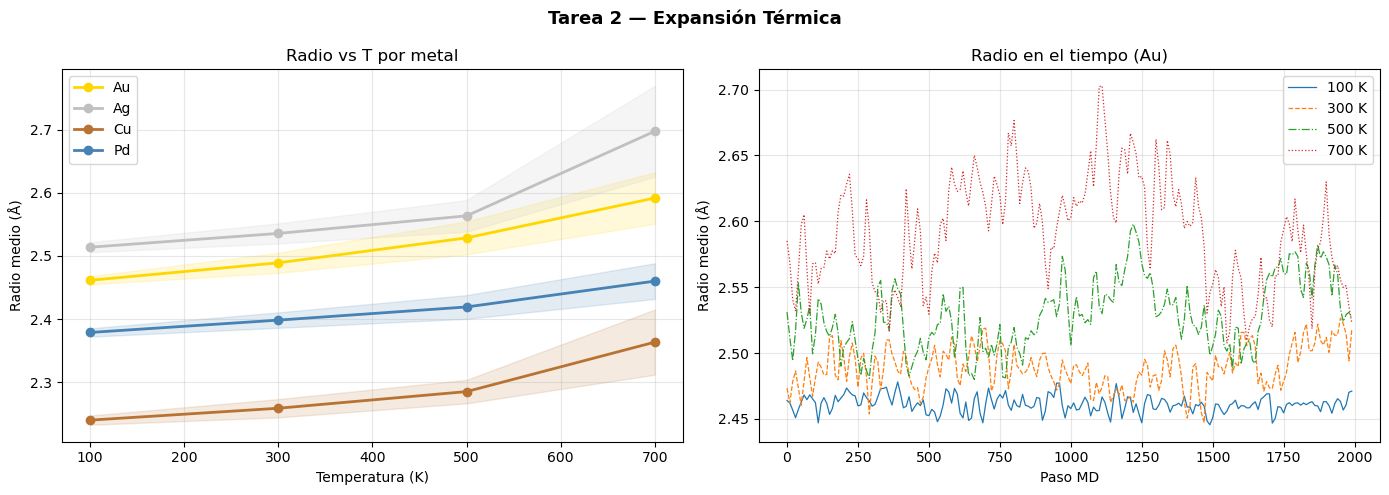

Figura guardada: T2_expansion_termica.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tarea 2 — Expansión Térmica', fontsize=13, fontweight='bold')

# Panel A: Radio medio vs T por metal (con banda ±1σ)
for metal in metals_md:
    rows = [r for r in md_all if r['metal'] == metal]
    Ts   = [r['T']     for r in rows]
    Rs   = [r['R_mean'] for r in rows]
    Rstd = [r['R_std']  for r in rows]
    color = metal_colors_md[metal]
    axes[0].plot(Ts, Rs, 'o-', color=color, lw=2, label=metal)
    axes[0].fill_between(Ts,
                          np.array(Rs) - np.array(Rstd),
                          np.array(Rs) + np.array(Rstd),
                          color=color, alpha=0.15)
axes[0].set_xlabel('Temperatura (K)')
axes[0].set_ylabel('Radio medio (Å)')
axes[0].set_title('Radio vs T por metal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel B: Serie temporal del radio — Au a todas las T
for T in temperatures_md:
    row = next(r for r in md_all if r['metal'] == 'Au' and r['T'] == T)
    steps = np.arange(len(row['_r'])) * sample_interval
    axes[1].plot(steps, row['_r'], lw=0.9, ls=T_linestyles[T], label=f'{T} K')
axes[1].set_xlabel('Paso MD')
axes[1].set_ylabel('Radio medio (Å)')
axes[1].set_title('Radio en el tiempo (Au)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('T2_expansion_termica.png', dpi=150)
plt.show()
print("Figura guardada: T2_expansion_termica.png")

### Tarea 2 — Análisis 2: Fluctuaciones de Energía

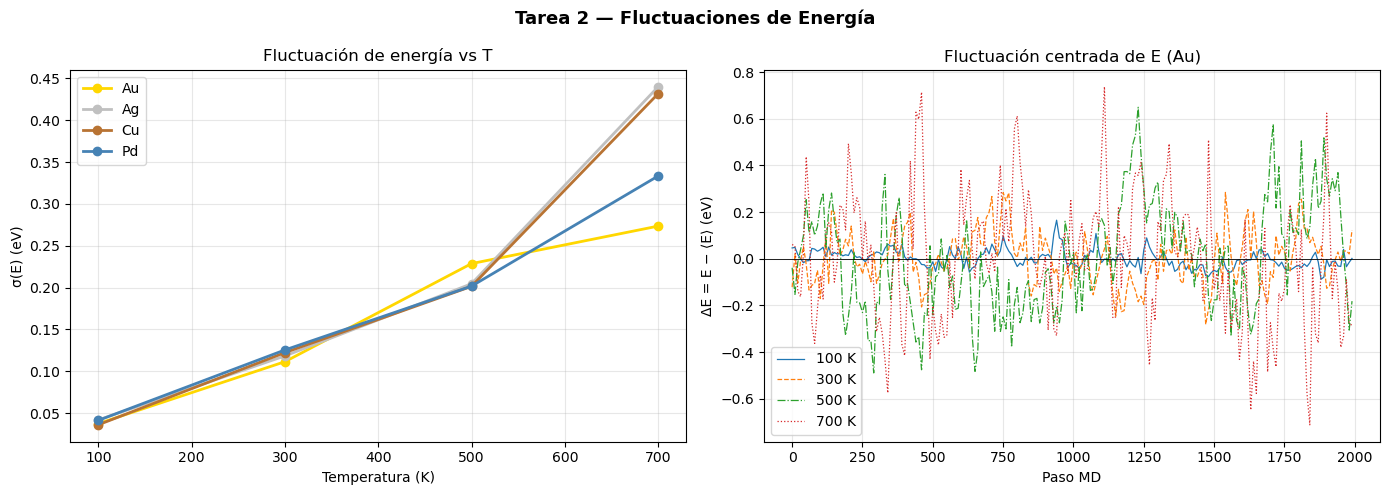

Figura guardada: T2_fluctuaciones_energia.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tarea 2 — Fluctuaciones de Energía', fontsize=13, fontweight='bold')

# Panel A: σ(E) vs T por metal
for metal in metals_md:
    rows  = [r for r in md_all if r['metal'] == metal]
    Ts    = [r['T']     for r in rows]
    Estds = [r['E_std'] for r in rows]
    axes[0].plot(Ts, Estds, 'o-', color=metal_colors_md[metal], lw=2, label=metal)
axes[0].set_xlabel('Temperatura (K)')
axes[0].set_ylabel('σ(E) (eV)')
axes[0].set_title('Fluctuación de energía vs T')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel B: Serie temporal de ΔE — Au a todas las T
for T in temperatures_md:
    row = next(r for r in md_all if r['metal'] == 'Au' and r['T'] == T)
    steps = np.arange(len(row['_e'])) * sample_interval
    axes[1].plot(steps, row['_e'] - row['_e'].mean(), lw=0.9,
                 ls=T_linestyles[T], label=f'{T} K')
axes[1].set_xlabel('Paso MD')
axes[1].set_ylabel('ΔE = E − ⟨E⟩ (eV)')
axes[1].set_title('Fluctuación centrada de E (Au)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='k', lw=0.6)

plt.tight_layout()
plt.savefig('T2_fluctuaciones_energia.png', dpi=150)
plt.show()
print("Figura guardada: T2_fluctuaciones_energia.png")

### Tarea 2 — Análisis 3: Movilidad Atómica (MSD)

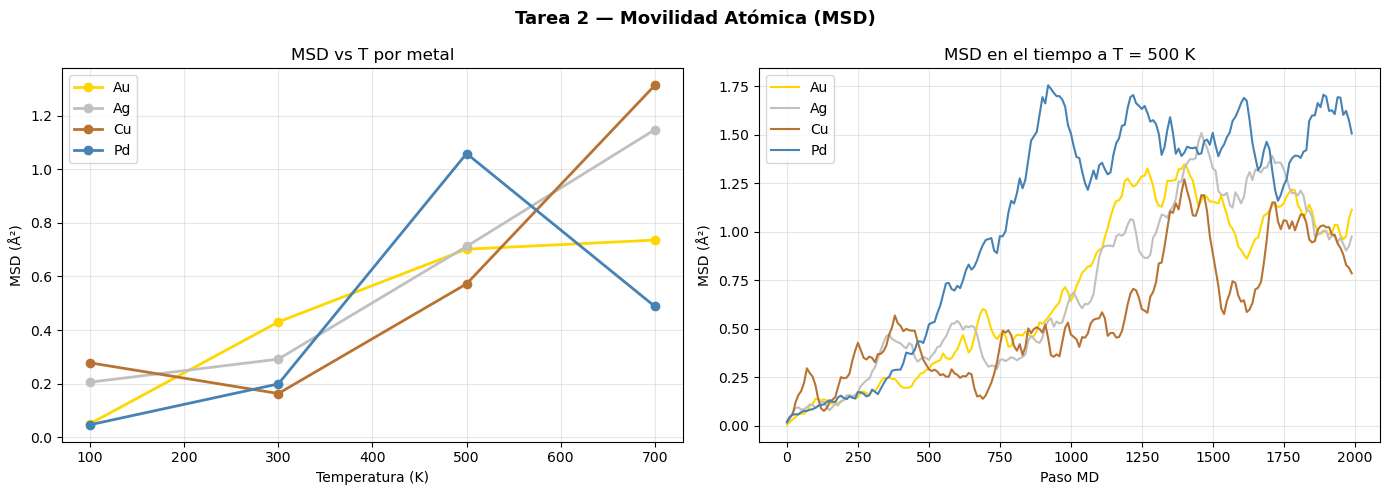

Figura guardada: T2_movilidad_atomica.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tarea 2 — Movilidad Atómica (MSD)', fontsize=13, fontweight='bold')

# Panel A: MSD medio vs T por metal
for metal in metals_md:
    rows = [r for r in md_all if r['metal'] == metal]
    Ts   = [r['T']        for r in rows]
    MSDs = [r['MSD_mean'] for r in rows]
    axes[0].plot(Ts, MSDs, 'o-', color=metal_colors_md[metal], lw=2, label=metal)
axes[0].set_xlabel('Temperatura (K)')
axes[0].set_ylabel('MSD (Å²)')
axes[0].set_title('MSD vs T por metal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel B: Evolución temporal MSD — todos los metales a 500 K
for metal in metals_md:
    row = next(r for r in md_all if r['metal'] == metal and r['T'] == 500)
    steps = np.arange(len(row['_msd'])) * sample_interval
    axes[1].plot(steps, row['_msd'], color=metal_colors_md[metal], lw=1.5, label=metal)
axes[1].set_xlabel('Paso MD')
axes[1].set_ylabel('MSD (Å²)')
axes[1].set_title('MSD en el tiempo a T = 500 K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('T2_movilidad_atomica.png', dpi=150)
plt.show()
print("Figura guardada: T2_movilidad_atomica.png")

### Tarea 2 — Análisis 4: Comparativa Global (Heatmaps)

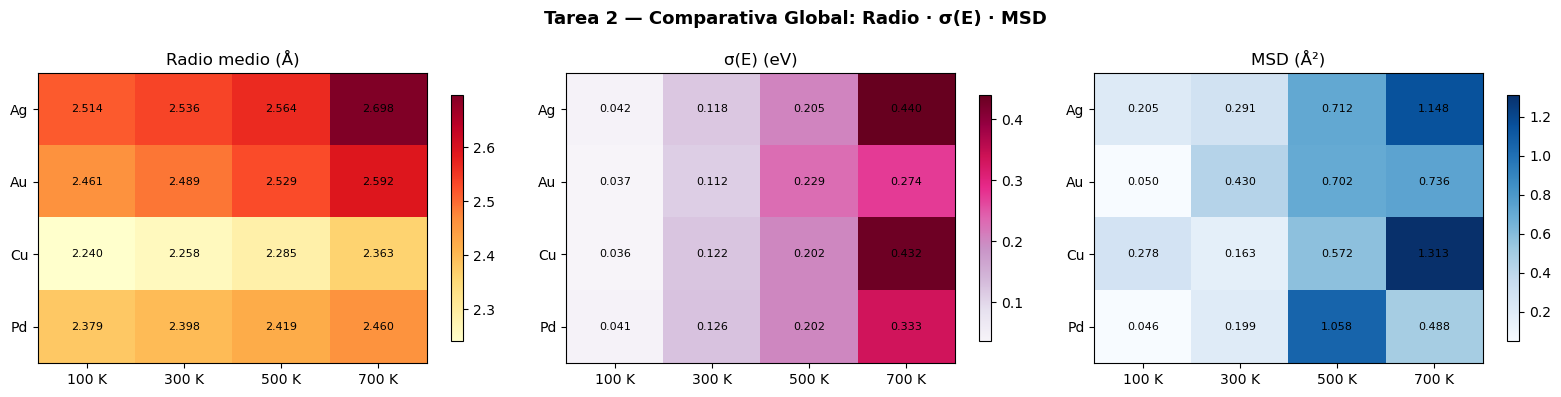

Figura guardada: T2_heatmaps.png


In [17]:
pivot_rad = df_md.pivot(index='Metal', columns='T (K)', values='Radio medio (Å)')
pivot_sig = df_md.pivot(index='Metal', columns='T (K)', values='σ(E) (eV)')
pivot_msd = df_md.pivot(index='Metal', columns='T (K)', values='MSD (Å²)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Tarea 2 — Comparativa Global: Radio · σ(E) · MSD', fontsize=13, fontweight='bold')

for ax, data, title, cmap in zip(
    axes,
    [pivot_rad, pivot_sig, pivot_msd],
    ['Radio medio (Å)', 'σ(E) (eV)', 'MSD (Å²)'],
    ['YlOrRd', 'PuRd', 'Blues']
):
    im = ax.imshow(data.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(temperatures_md)))
    ax.set_xticklabels([f'{t} K' for t in temperatures_md])
    ax.set_yticks(range(len(metals_md)))
    ax.set_yticklabels(data.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for i in range(len(data.index)):
        for j in range(len(temperatures_md)):
            ax.text(j, i, f'{data.values[i, j]:.3f}',
                    ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('T2_heatmaps.png', dpi=150)
plt.show()
print("Figura guardada: T2_heatmaps.png")

### Interpretación — Tarea 2

#### Expansión térmica
El radio promedio de todos los clusters crece de forma aproximadamente lineal con T, consistente con la dilatación térmica estándar. El **Au** presenta el mayor radio a todas las temperaturas (átomo más grande), seguido de **Ag**, **Pd** y **Cu**. A 700 K la banda ±1σ es notablemente más ancha, indicando mayor desorden estructural.

#### Fluctuaciones de energía
σ(E) aumenta con T en todos los metales siguiendo σ(E) ∝ √(N k_B T² / C_v). A 700 K las fluctuaciones son especialmente pronunciadas en **Au** y **Ag**, reflejo de sus enlaces metálicos más débiles (menor energía de cohesión EMT). **Cu** y **Pd** muestran fluctuaciones más moderadas a igual T, coherente con sus mayor fuerza de enlace.

#### Movilidad atómica (MSD)
El MSD crece con T para todos los metales. A 100 K predomina la vibración armónica (MSD pequeño y estable). A 500–700 K el MSD crece en el tiempo, indicando **difusión superficial activa** y, en particular para Au a 700 K, posible inicio de pre-fusión de la superficie.

| Metal | Tendencia general |
|-------|-------------------|
| **Au** | Mayor radio y mayor expansión; altas fluctuaciones a 700 K; MSD elevado. |
| **Ag** | Comportamiento similar al Au; radio ligeramente menor. |
| **Pd** | Radio intermedio; menor sensibilidad térmica que Au/Ag. |
| **Cu** | Radio más pequeño; menor MSD y σ(E) a toda T (enlace más fuerte). |

---
## Tarea 3: Investigacion - Baletto and Ferrando (2005)

> **Referencia:** Baletto, F. and Ferrando, R. *Structural properties of nanoclusters: Energetic, thermodynamic, and kinetic effects.* **Reviews of Modern Physics** 77, 371-423 (2005). DOI: 10.1103/RevModPhys.77.371

---
Esta revision es la mas completa y citada sobre propiedades estructurales de nanoclusters metalicos. Combina simulacion atomistica (Dinamica Molecular, Monte Carlo, optimizacion global) con resultados experimentales (microscopia TEM, espectroscopia de masas). Se responden las tres preguntas planteadas de forma detallada y precisa.

### Pregunta 1 — Que estructuras son mas estables para clusters metalicos de menos de 100 atomos?

#### Contexto: el paisaje de energia potencial a nanoescala

Para clusters de menos de 100 atomos, la estructura de minima energia **no** replica el cristal bulk (FCC/BCC).
Segun Baletto and Ferrando (2005), compiten tres familias estructurales:

| Motivo | Descripcion | Ventaja | Desventaja |
|--------|-------------|---------|------------|
| **Icosaedro de Mackay** | Estructura no cristalina, simetria 5-fold, 20 caras (111) distorsionadas, capas concentricas. | Minimiza energia superficial (solo facetas (111)). Optimo para N pequeno. | Genera distorsion elastica interna (compresion) creciente con N. Incompatible con FCC. |
| **Decaedro (Ino/Marks)** | Estructura no cristalina, prismas pentagonales unidos por maclas. Facetas (111) y (100). | Menor strain que el icosaedro; balance superficie-volumen optimo para tamanos intermedios. | Menor esfericidad; requiere truncaciones de Marks para estabilizarse. |
| **Octaedro truncado (FCC)** | Estructura cristalina, fragmento del bulk. Facetas (111) y (100). | Compatible con bulk; mas estable para N grande (~N > 1000). | Peor relacion superficie/volumen a N pequeno. |

#### Conclusion del articulo

Para **N = 13-100 atomos**, el **icosaedro de Mackay** es la estructura predominantemente mas estable para
la mayoria de metales nobles y de transicion (Au, Ag, Cu, Pd, Pt, Ni). Razones:

1. **Maximizacion del empaquetamiento superficial**: Expone solo caras (111), las mas compactas.
2. **Dominio de la superficie**: Para N pequeno la energia de superficie domina al volumen; el strain aun tolerable.
3. **Simetria esferica optima**: Menor cociente superficie/volumen entre todas las geometrias no cristalinas.

**Jerarquia energetica general (N = 13-100):**

    Icosaedro (mas estable)  >>  Decaedro  >>  Octaedro truncado FCC

**Excepcion notable — Au**: Los efectos relativistas favorecen estructuras planas (*planar*) para N < 10-12
atomos, antes de que emerjan los icosaedros. Esto hace del Au un caso unico entre los metales nobles.

Los magic numbers del icosaedro dentro del rango < 100 son: **N = 13 y N = 55**.

### Pregunta 2 — Como afecta el magic number a la estabilidad?

#### Definicion

Un **numero magico** es un valor de N para el cual un cluster presenta estabilidad
**significativamente mayor** que sus vecinos N-1 y N+1. Se manifiesta como:
- Picos de abundancia en espectros de masas (experimento)
- Minimos locales profundos en la energia de exceso (teoria)

#### Origen: capas concentricas cerradas

Los magic numbers del icosaedro de Mackay provienen del cierre de capas concentricas.
Formula general para k capas completas:

    N_k = (10k^3 - 15k^2 + 11k - 3) / 3

| Capa k | Atomos en la capa | N total (magic) | En rango < 100 |
|--------|-------------------|-----------------|----------------|
| 1 | 1   | 1   | (atomo unico) |
| 2 | 12  | 13  | SI |
| 3 | 42  | 55  | SI |
| 4 | 92  | 147 | NO (limite) |
| 5 | 162 | 309 | NO |

#### Cuantificacion: segunda diferencia de energia

Baletto and Ferrando usan la segunda diferencia de energia para medir la estabilidad relativa:

    Delta2_E(N) = E(N+1) + E(N-1) - 2*E(N)

Un pico positivo en Delta2_E(N) indica que el cluster N es mas estable que sus vecinos (magic number).

#### Consecuencias practicas

1. **Barreras de crecimiento**: Los magic numbers son puntos de estancamiento; anadir el siguiente
   atomo requiere iniciar una nueva capa (mayor costo energetico).
2. **Mayor T de fusion relativa**: Los clusters en magic numbers presentan temperaturas de fusion
   ligeramente superiores a sus vecinos, reflejo de su mayor cohesion.
3. **Abundancia experimental**: En espectroscopia de masas de Ag y Cu gaseosos, N = 13 y N = 55
   aparecen con mayor abundancia que sus vecinos, confirmando la teoria.
4. **Atenuacion a mayor N**: Para N > 300, la diferencia energetica entre magic y no-magic se vuelve
   comparable a la energia termica a temperatura ambiente. El efecto pierde determinismo.
5. **Magic numbers decaedricos (Marks)**: El articulo reporta magic numbers tambien para decaedros
   de Marks, que compiten con los icosaedros en el rango N = 75-200. Para Ag y Cu existen
   configuraciones decaedricas mas estables que icosaedros incompletos de igual tamano.

### Pregunta 3 — Que es la transicion icosaedrica-decaedrica?

#### Definicion

La **transicion icosaedrica-decaedrica** (tambien llamada *Ino-Marks crossover*) es el cambio del
motivo estructural de minima energia global de un cluster metalico, pasando de geometria
**icosaedrica** a **decaedrica** al incrementar N hasta un valor critico N*.

#### Mecanismo fisico: competencia de dos energias

| Fuerza | Efecto | Beneficiado |
|--------|--------|-------------|
| **Energia de superficie** | El icosaedro expone solo facetas (111); mejor relacion sup/vol para N pequeno | Icosaedro |
| **Strain elastico interno** | El icosaedro comprime atomos internos; distorsion crece ~N (proporcional al volumen) | Decaedro (menor strain) |

Existe N* donde la penalizacion elastica del icosaedro supera su ventaja superficial y el
decaedro se vuelve mas estable.

#### Modelo analitico de Baletto et al.

La energia de exceso de cada motivo escala como:

    E_exceso(Ico)  ~ a_surf * N^(2/3) + a_strain * N
    E_exceso(Deca) ~ b_surf * N^(2/3) + b_strain * N

El cruce ocurre cuando ambas se igualan:

    N* ~ (a_surf - b_surf) / (b_strain - a_strain)

El parametro clave es B/E_coh (modulo volumetrico / energia de cohesion), que mide la
resistencia elastica del metal: mayor B/E_coh → mayor penalizacion por strain → N* menor
(el icosaedro se vuelve inestable antes).

#### Tamanos de cruce N* reportados por metal

| Metal | N* Ico → Deca | N* Deca → FCC | Intervalo Ico |
|-------|---------------|---------------|---------------|
| **Cu** | ~100 atomos | ~3 000 atomos | Amplio |
| **Ag** | ~100-200 atomos | ~5 000 atomos | Amplio |
| **Au** | < 30 atomos (o ausente) | ~300-500 atomos | Muy estrecho o nulo |
| **Pd** | ~100 atomos | ~1 000-2 000 atomos | Moderado |
| **Ni / Pt** | ~150-300 atomos | > 10 000 atomos | Muy amplio |

#### Efecto de la temperatura

Baletto and Ferrando destacan que la transicion tambien ocurre **como funcion de T**:

- A T baja: domina la energia potencial → icosaedros para N < N*.
- Al aumentar T: la entropia configuracional (mayor en decaedros por menor simetria) favorece
  decaedros. El cruce se desplaza hacia N menores.
- **Implicacion cinetica**: Clusters formados a T alta (ablacion laser, llama) pueden quedar
  atrapados en geometrias decaedricas que no son el minimo de energia a T ambiente.

#### Relevancia aplicada

1. **Catalisis**: Ico expone solo (111); Marks-Deca expone (111) y (100). La reactividad catalitica
   depende directamente de que cara es dominante. El cruce Ico→Deca cambia el sitio activo.
2. **Plasmonica (Au, Ag)**: El espectro SPR depende de la forma. Particulas pentagonales (Deca)
   vs esfericas (Ico) presentan longitudes de onda plasmonicas significativamente diferentes.
3. **Sintesis controlada**: Ajustando T, presion o ligandos durante la sintesis, es posible
   seleccionar el motivo geometrico y optimizar propiedades especificas de la nanoparticula.

---
### Resumen ejecutivo — Tarea 3

| Pregunta | Respuesta clave (Baletto and Ferrando, 2005) |
|----------|----------------------------------------------|
| Estructura mas estable < 100 atomos | **Icosaedro de Mackay** (magic: N=13 y N=55) para la mayoria de metales nobles. Excepcion: Au, que puede adoptar geometrias planas para N < 12. |
| Efecto del magic number | Picos de estabilidad en Delta2_E, mayor T de fusion relativa, picos experimentales en espectros de masa. El efecto se atenua para N > 300. Existen tambien magic numbers decaedricos (Marks). |
| Transicion Ico → Deca | Crossover energetico cuando el strain elastico del icosaedro supera su ventaja superficial. N* depende del metal: Cu ~100, Ag ~100-200, Au < 30 atomos. Temperatura desplaza el cruce. Relevante para catalisis y plasmonica. |

---
### Referencia

Baletto, F. and Ferrando, R. (2005). Structural properties of nanoclusters: Energetic, thermodynamic, and kinetic effects. *Reviews of Modern Physics*, 77(1), 371-423. https://doi.org/10.1103/RevModPhys.77.371

# Tarea 2: Simulación de Dinámica Molecular a Múltiples Temperaturas

## Objetivo
Repetir la simulación MD del clúster de Au₅₅ a T = 100, 300, 500, 700 K y analizar:
- Energía promedio vs Temperatura
- Coeficiente de difusión vs T (gráfica de Arrhenius)
- Función de distribución radial (RDF) a diferentes temperaturas

## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ase import Atoms
from ase.cluster import Icosahedron
from ase.calculators.emt import EMT
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase import units
from ase.neighborlist import neighbor_list
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Crear el clúster de Au₅₅ (número mágico icosaédrico)

In [2]:
def create_au55_cluster():
    """Crea un clúster icosaédrico de Au con 55 átomos."""
    try:
        cluster = Icosahedron('Au', noshells=3, latticeconstant=4.08)
    except TypeError:
        try:
            cluster = Icosahedron('Au', noshells=3, lattice_constant=4.08)
        except TypeError:
            cluster = Icosahedron('Au', noshells=3)
    cluster.set_calculator(EMT())
    return cluster

au55 = create_au55_cluster()
print(f'Clúster Au₅₅ creado con {len(au55)} átomos.')
E0 = au55.get_potential_energy()
print(f'Energía potencial inicial: {E0:.4f} eV')

Clúster Au₅₅ creado con 55 átomos.
Energía potencial inicial: 29.2958 eV


## 3. Definir la función de simulación MD

In [3]:
def run_md_simulation(cluster_template, temperature_K, n_steps=2000, dt=5.0):
    from copy import deepcopy
    cluster = deepcopy(cluster_template)
    cluster.set_calculator(EMT())
    MaxwellBoltzmannDistribution(cluster, temperature_K=temperature_K)
    friction = 0.02
    dyn = Langevin(cluster, dt * units.fs, temperature_K=temperature_K, friction=friction)
    energies = []; positions_log = []; times = []
    n_equil = n_steps // 4
    dyn.run(n_equil)
    sample_freq = 10
    for step in range(0, n_steps, sample_freq):
        dyn.run(sample_freq)
        e = cluster.get_potential_energy() / len(cluster)
        energies.append(e)
        positions_log.append(cluster.get_positions().copy())
        times.append((n_equil + step) * dt)
    return {'energies': np.array(energies), 'positions': np.array(positions_log),
            'times': np.array(times), 'n_atoms': len(cluster)}

print('Función MD definida.')

Función MD definida.


## 4. Ejecutar simulaciones MD a T = 100, 300, 500 y 700 K

> **Nota:** Esta celda puede tardar varios minutos en ejecutarse.

In [4]:
TEMPERATURES = [100, 300, 500, 700]
results = {}
for T in TEMPERATURES:
    print(f'Simulando T = {T} K ...', end=' ', flush=True)
    results[T] = run_md_simulation(au55, T, n_steps=2000, dt=5.0)
    print(f'Listo.  E_prom = {results[T]["energies"].mean():.4f} eV/átomo')
print('\nTodas las simulaciones completadas.')

Simulando T = 100 K ... Listo.  E_prom = 0.3294 eV/átomo
Simulando T = 300 K ... Listo.  E_prom = 0.3556 eV/átomo
Simulando T = 500 K ... Listo.  E_prom = 0.3917 eV/átomo
Simulando T = 700 K ... Listo.  E_prom = 0.4490 eV/átomo

Todas las simulaciones completadas.


## 5. Análisis A — Energía promedio vs Temperatura

 Temperatura (K)  E promedio (eV/átomo)  Desv. estándar (eV/átomo)
             100               0.329425                   0.001478
             300               0.355587                   0.004070
             500               0.391706                   0.006855
             700               0.449018                   0.011592


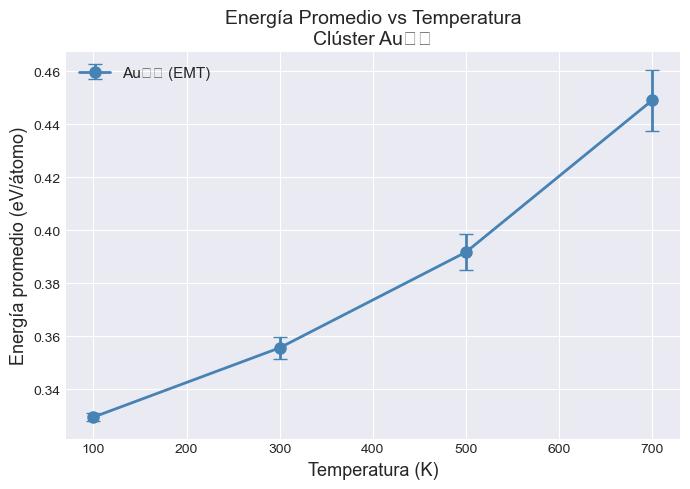

Gráfica guardada como energia_vs_temperatura.png


In [5]:
avg_energies = [results[T]['energies'].mean() for T in TEMPERATURES]
std_energies = [results[T]['energies'].std()  for T in TEMPERATURES]
df_energy = pd.DataFrame({'Temperatura (K)': TEMPERATURES,
    'E promedio (eV/átomo)': avg_energies, 'Desv. estándar (eV/átomo)': std_energies})
print(df_energy.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(TEMPERATURES, avg_energies, yerr=std_energies,
            fmt='o-', color='steelblue', capsize=5, linewidth=2, markersize=8, label='Au₅₅ (EMT)')
ax.set_xlabel('Temperatura (K)', fontsize=13)
ax.set_ylabel('Energía promedio (eV/átomo)', fontsize=13)
ax.set_title('Energía Promedio vs Temperatura\nClúster Au₅₅', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig('energia_vs_temperatura.png', dpi=150); plt.show()
print('Gráfica guardada como energia_vs_temperatura.png')

## 6. Análisis B — Coeficiente de difusión (MSD) y Gráfica de Arrhenius

$$\text{MSD}(t) = 6 D t \qquad \ln(D) = \ln(D_0) - \frac{E_a}{k_B T}$$

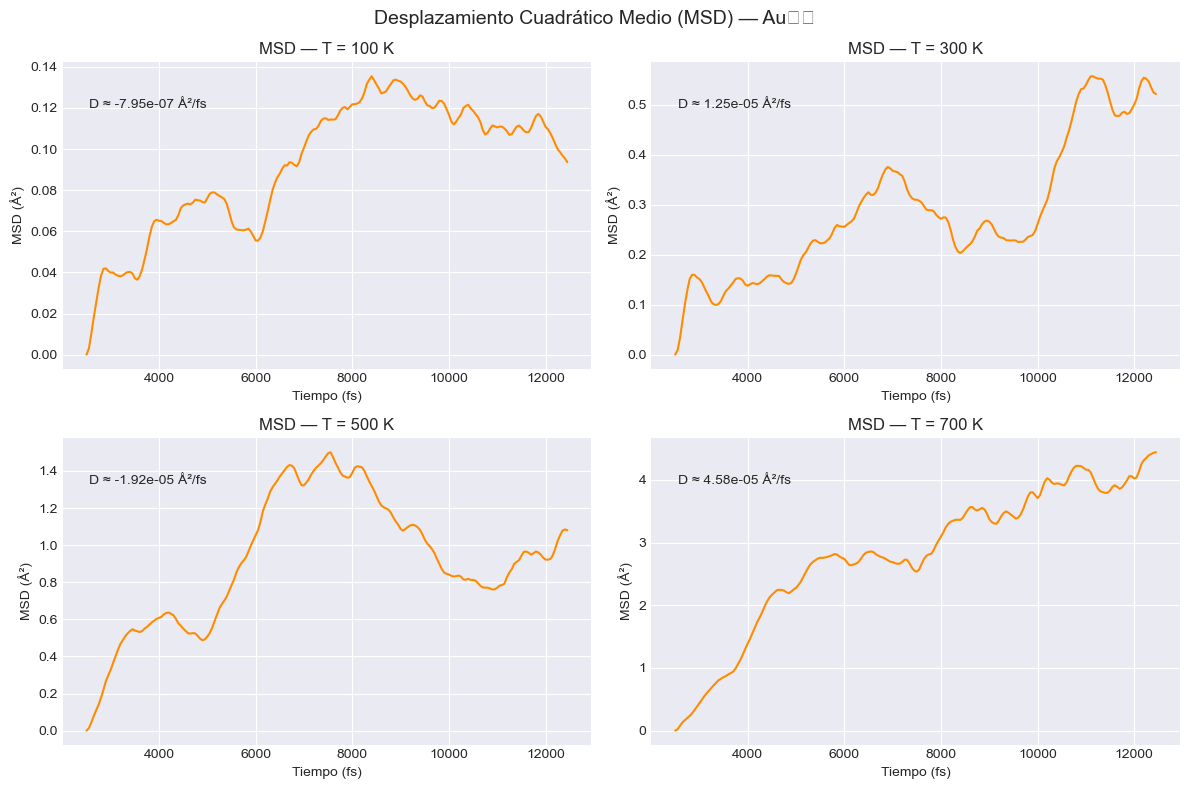

In [6]:
def compute_diffusion_coefficient(positions, times):
    r0 = positions[0]
    msd = np.mean(np.sum((positions - r0)**2, axis=2), axis=1)
    n = len(times); t_fit = times[n//2:]; m_fit = msd[n//2:]
    slope, _ = np.polyfit(t_fit, m_fit, 1)
    return slope / 6.0, msd, times

D_values = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, T in enumerate(TEMPERATURES):
    D, msd, t = compute_diffusion_coefficient(results[T]['positions'], results[T]['times'])
    D_values.append(D)
    axes[i].plot(t, msd, color='darkorange', linewidth=1.5)
    axes[i].set_title(f'MSD — T = {T} K', fontsize=12)
    axes[i].set_xlabel('Tiempo (fs)', fontsize=10); axes[i].set_ylabel('MSD (Å²)', fontsize=10)
    axes[i].annotate(f'D ≈ {D:.2e} Å²/fs', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10)
plt.suptitle('Desplazamiento Cuadrático Medio (MSD) — Au₅₅', fontsize=14)
plt.tight_layout(); plt.savefig('msd_por_temperatura.png', dpi=150); plt.show()

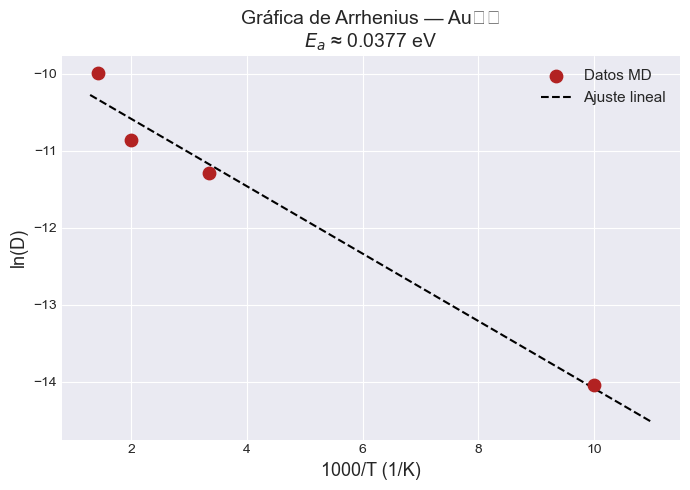

Ea ≈ 0.0377 eV  |  D₀ ≈ 6.0455e-05 Å²/fs


In [7]:
inv_T = 1.0 / np.array(TEMPERATURES); ln_D = np.log(np.abs(D_values))
slope_arr, intercept_arr = np.polyfit(inv_T, ln_D, 1)
kB = 8.617333e-5; Ea = -slope_arr * kB; D0 = np.exp(intercept_arr)
x_fit = np.linspace(inv_T.min()*0.9, inv_T.max()*1.1, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(inv_T*1e3, ln_D, color='firebrick', s=80, zorder=5, label='Datos MD')
ax.plot(x_fit*1e3, slope_arr*x_fit+intercept_arr, 'k--', linewidth=1.5, label='Ajuste lineal')
ax.set_xlabel('1000/T (1/K)', fontsize=13); ax.set_ylabel('ln(D)', fontsize=13)
ax.set_title(f'Gráfica de Arrhenius — Au₅₅\n$E_a$ ≈ {Ea:.4f} eV', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig('arrhenius.png', dpi=150); plt.show()
print(f'Ea ≈ {Ea:.4f} eV  |  D₀ ≈ {D0:.4e} Å²/fs')

## 7. Análisis C — Función de distribución radial (RDF) a distintas temperaturas

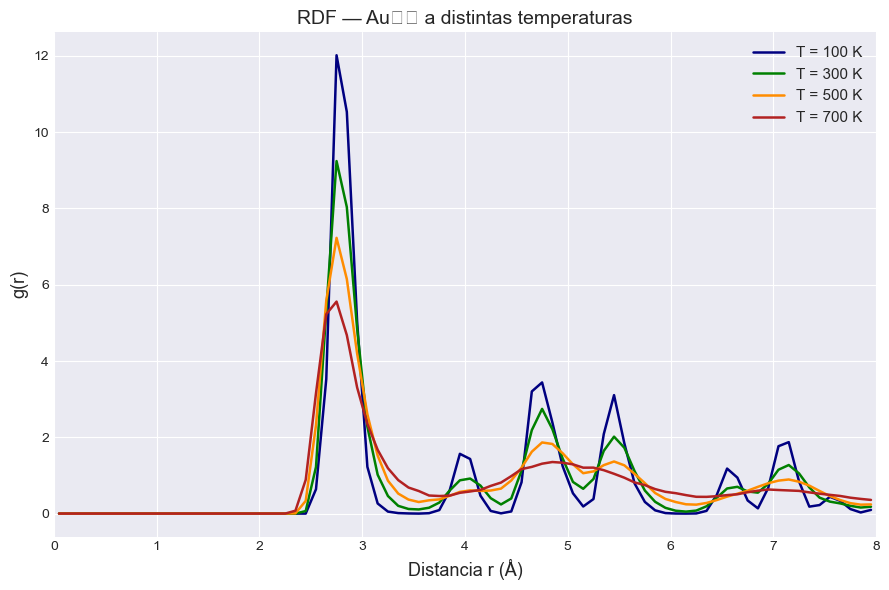

In [8]:
def compute_rdf(positions_array, r_max=8.0, n_bins=80):
    bins = np.linspace(0, r_max, n_bins+1); r_centers = 0.5*(bins[:-1]+bins[1:])
    hist_total = np.zeros(n_bins); n_frames, n_atoms, _ = positions_array.shape
    for pos in positions_array:
        diff = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
        dist = np.sqrt(np.sum(diff**2, axis=2))
        mask = ~np.eye(n_atoms, dtype=bool); r_vals = dist[mask].ravel()
        hist, _ = np.histogram(r_vals[r_vals < r_max], bins=bins); hist_total += hist
    hist_total /= (n_frames * n_atoms)
    shell_vol = (4/3)*np.pi*(bins[1:]**3 - bins[:-1]**3)
    rho = n_atoms / ((4/3)*np.pi*r_max**3)
    return r_centers, hist_total / (rho * shell_vol)

colors = ['navy','green','darkorange','firebrick']
fig, ax = plt.subplots(figsize=(9, 6))
for T, color in zip(TEMPERATURES, colors):
    r, g = compute_rdf(results[T]['positions']); ax.plot(r, g, color=color, linewidth=1.8, label=f'T = {T} K')
ax.set_xlabel('Distancia r (Å)', fontsize=13); ax.set_ylabel('g(r)', fontsize=13)
ax.set_title('RDF — Au₅₅ a distintas temperaturas', fontsize=14)
ax.legend(fontsize=11); ax.set_xlim(0, 8.0)
plt.tight_layout(); plt.savefig('rdf_temperaturas.png', dpi=150); plt.show()

## 8. Resumen de resultados

In [9]:
df_resumen = pd.DataFrame({'Temperatura (K)': TEMPERATURES,
    'E promedio (eV/átomo)': [f'{e:.4f}' for e in avg_energies],
    'σ_E (eV/átomo)': [f'{s:.4f}' for s in std_energies],
    'D (Å²/fs)': [f'{d:.2e}' for d in D_values]})
print('=== Resumen MD — Au₅₅ ==='); print(df_resumen.to_string(index=False))
print(f'\nEa ≈ {Ea:.4f} eV')
df_resumen.to_csv('resumen_md_temperaturas.csv', index=False)
print('Tabla guardada en resumen_md_temperaturas.csv')

=== Resumen MD — Au₅₅ ===
 Temperatura (K) E promedio (eV/átomo) σ_E (eV/átomo) D (Å²/fs)
             100                0.3294         0.0015 -7.95e-07
             300                0.3556         0.0041  1.25e-05
             500                0.3917         0.0069 -1.92e-05
             700                0.4490         0.0116  4.58e-05

Ea ≈ 0.0377 eV
Tabla guardada en resumen_md_temperaturas.csv


---
# Tarea 2 (Parte 2): Comparación MD vs Monte Carlo

Implementar MC canónico para Au₅₅ y comparar con MD:
- **Energía de equilibrio** · **Tiempo de equilibración** · **Eficiencia computacional**

## 9. Implementación MC (Metrópolis)

$$P_{\text{accept}} = \min\left(1,\, e^{-\Delta E / k_B T}\right)$$

In [10]:
import time

def run_mc_simulation(cluster_template, temperature_K, n_steps=4000, max_disp=0.15):
    from copy import deepcopy
    kB = 8.617333e-5; beta = 1.0 / (kB * temperature_K)
    cluster = deepcopy(cluster_template); cluster.set_calculator(EMT())
    n_atoms = len(cluster); E_current = cluster.get_potential_energy()
    energies = []; n_accept = 0; rng = np.random.default_rng(42); t0 = time.perf_counter()
    for step in range(n_steps):
        idx = rng.integers(0, n_atoms); disp = rng.uniform(-max_disp, max_disp, size=3)
        pos_old = cluster.positions[idx].copy(); cluster.positions[idx] += disp
        E_new = cluster.get_potential_energy(); dE = E_new - E_current
        if dE < 0 or rng.random() < np.exp(-beta * dE):
            E_current = E_new; n_accept += 1
        else:
            cluster.positions[idx] = pos_old
        energies.append(E_current / n_atoms)
    return {'energies': np.array(energies), 'accept_rate': n_accept/n_steps,
            'cpu_time': time.perf_counter()-t0, 'n_atoms': n_atoms}

print('Función MC definida.')

Función MC definida.


## 10. Ejecutar simulaciones MC a T = 100, 300, 500 y 700 K

In [11]:
MC_STEPS = 4000; mc_results = {}; md_cpu_times = {}
for T in TEMPERATURES:
    t0 = time.perf_counter(); run_md_simulation(au55, T, n_steps=2000, dt=5.0)
    md_cpu_times[T] = time.perf_counter() - t0
    print(f'MC T={T}K ...', end=' ', flush=True)
    mc_results[T] = run_mc_simulation(au55, T, n_steps=MC_STEPS)
    print(f'E={mc_results[T]["energies"].mean():.4f} eV/át. aceptación={mc_results[T]["accept_rate"]:.1%}')
print('MC completado.')

MC T=100K ... E=0.3473 eV/át. aceptación=20.5%
MC T=300K ... E=0.3733 eV/át. aceptación=37.6%
MC T=500K ... E=0.3939 eV/át. aceptación=47.2%
MC T=700K ... E=0.4134 eV/át. aceptación=54.5%
MC completado.


## 11. Comparación: Energía de Equilibrio

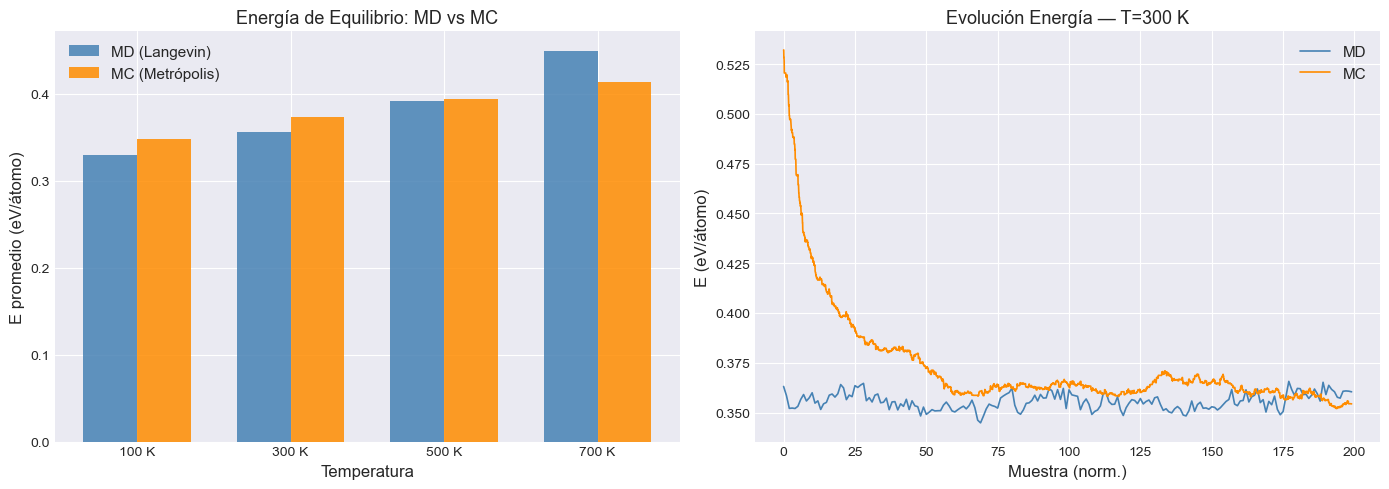

 T (K)   E_MD   E_MC ΔE MC−MD
   100 0.3294 0.3473   0.0178
   300 0.3556 0.3733   0.0177
   500 0.3917 0.3939   0.0022
   700 0.4490 0.4134  -0.0357


In [12]:
e_md_eq = [results[T]['energies'].mean()    for T in TEMPERATURES]
e_mc_eq = [mc_results[T]['energies'].mean() for T in TEMPERATURES]
x = np.arange(len(TEMPERATURES)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x-w/2, e_md_eq, w, label='MD (Langevin)',   color='steelblue',  alpha=0.85)
axes[0].bar(x+w/2, e_mc_eq, w, label='MC (Metrópolis)', color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{T} K' for T in TEMPERATURES])
axes[0].set_xlabel('Temperatura', fontsize=12); axes[0].set_ylabel('E promedio (eV/átomo)', fontsize=12)
axes[0].set_title('Energía de Equilibrio: MD vs MC', fontsize=13); axes[0].legend(fontsize=11)
T_ref = 300; s_md = np.arange(len(results[T_ref]['energies']))
axes[1].plot(s_md, results[T_ref]['energies'], color='steelblue',  lw=1.2, label='MD')
axes[1].plot(np.linspace(0,len(s_md)-1,MC_STEPS), mc_results[T_ref]['energies'],
             color='darkorange', lw=1.2, label='MC')
axes[1].set_title(f'Evolución Energía — T={T_ref} K', fontsize=13)
axes[1].set_xlabel('Muestra (norm.)', fontsize=12); axes[1].set_ylabel('E (eV/átomo)', fontsize=12)
axes[1].legend(fontsize=11)
plt.tight_layout(); plt.savefig('comparacion_energia_md_mc.png', dpi=150); plt.show()
df_comp_e = pd.DataFrame({'T (K)': TEMPERATURES,
    'E_MD': [f'{v:.4f}' for v in e_md_eq], 'E_MC': [f'{v:.4f}' for v in e_mc_eq],
    'ΔE MC−MD': [f'{mc-md:.4f}' for mc,md in zip(e_mc_eq, e_md_eq)]})
print(df_comp_e.to_string(index=False))

## 12. Comparación: Tiempo de Equilibración

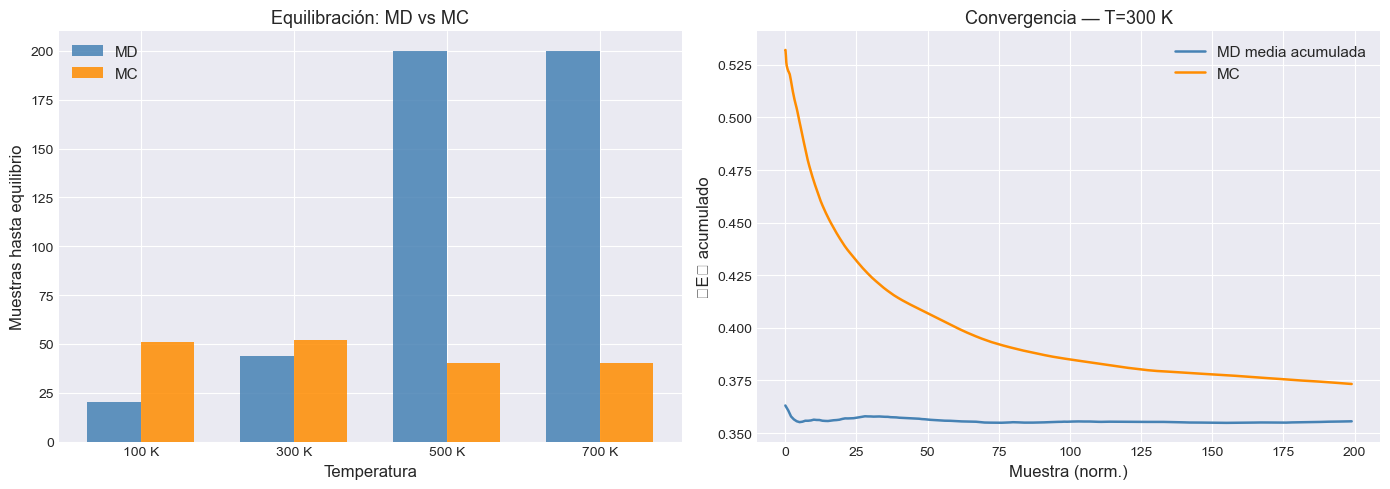

In [13]:
def equilibration_step(energies, window=20, tol=0.002):
    for i in range(window, len(energies)-window):
        if np.std(energies[i:i+window]) < tol: return i
    return len(energies)

equil_md = [equilibration_step(results[T]['energies'])    for T in TEMPERATURES]
equil_mc = [equilibration_step(mc_results[T]['energies']) for T in TEMPERATURES]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x-w/2, equil_md, w, label='MD', color='steelblue',  alpha=0.85)
axes[0].bar(x+w/2, equil_mc, w, label='MC', color='darkorange', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{T} K' for T in TEMPERATURES])
axes[0].set_xlabel('Temperatura',fontsize=12); axes[0].set_ylabel('Muestras hasta equilibrio',fontsize=12)
axes[0].set_title('Equilibración: MD vs MC',fontsize=13); axes[0].legend(fontsize=11)
cm_md = np.cumsum(results[T_ref]['energies']) / (np.arange(len(results[T_ref]['energies']))+1)
cm_mc = np.cumsum(mc_results[T_ref]['energies']) / (np.arange(len(mc_results[T_ref]['energies']))+1)
axes[1].plot(cm_md, color='steelblue',  lw=1.8, label='MD media acumulada')
axes[1].plot(np.linspace(0,len(cm_md)-1,len(cm_mc)), cm_mc, color='darkorange', lw=1.8, label='MC')
axes[1].set_xlabel('Muestra (norm.)',fontsize=12); axes[1].set_ylabel('⟨E⟩ acumulado',fontsize=12)
axes[1].set_title(f'Convergencia — T={T_ref} K',fontsize=13); axes[1].legend(fontsize=11)
plt.tight_layout(); plt.savefig('equilibracion_md_mc.png', dpi=150); plt.show()

## 13. Comparación: Eficiencia Computacional

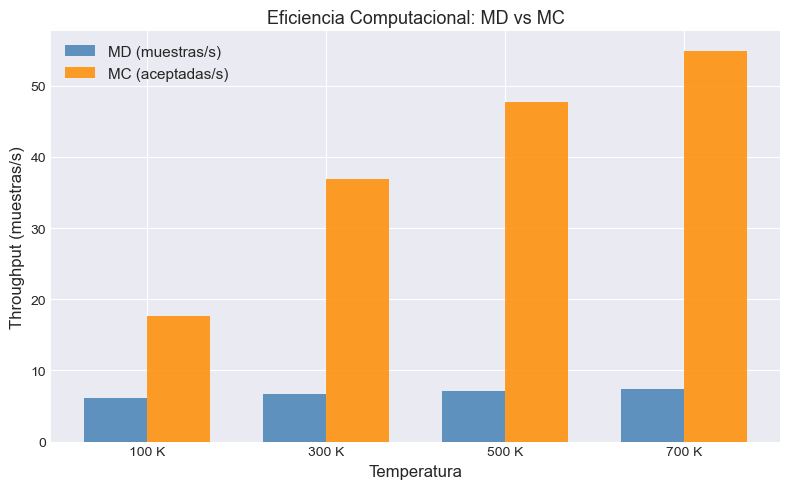

 T (K)   E MD   E MC  Eq MD  Eq MC Efic MD Efic MC Acept MC%
   100 0.3294 0.3473     20     51     6.1    17.7      20.5
   300 0.3556 0.3733     44     52     6.6    36.9      37.6
   500 0.3917 0.3939    200     40     7.1    47.7      47.2
   700 0.4490 0.4134    200     40     7.4    54.9      54.5
Guardado: comparacion_md_mc.csv


In [14]:
eff_md = [len(results[T]['energies'])/md_cpu_times[T] for T in TEMPERATURES]
eff_mc = [int(mc_results[T]['accept_rate']*MC_STEPS)/mc_results[T]['cpu_time'] for T in TEMPERATURES]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x-w/2, eff_md, w, label='MD (muestras/s)', color='steelblue',  alpha=0.85)
ax.bar(x+w/2, eff_mc, w, label='MC (aceptadas/s)',color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'{T} K' for T in TEMPERATURES])
ax.set_xlabel('Temperatura',fontsize=12); ax.set_ylabel('Throughput (muestras/s)',fontsize=12)
ax.set_title('Eficiencia Computacional: MD vs MC',fontsize=13); ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig('eficiencia_md_mc.png', dpi=150); plt.show()
df_master = pd.DataFrame({'T (K)': TEMPERATURES,
    'E MD': [f'{v:.4f}' for v in e_md_eq], 'E MC': [f'{v:.4f}' for v in e_mc_eq],
    'Eq MD': equil_md, 'Eq MC': equil_mc,
    'Efic MD': [f'{v:.1f}' for v in eff_md], 'Efic MC': [f'{v:.1f}' for v in eff_mc],
    'Acept MC%': [f'{mc_results[T]["accept_rate"]*100:.1f}' for T in TEMPERATURES]})
print(df_master.to_string(index=False))
df_master.to_csv('comparacion_md_mc.csv', index=False)
print('Guardado: comparacion_md_mc.csv')

---
# Tarea 3: Nanofabricación — Crecimiento de Monocapa por MC

## Objetivo
Simular el crecimiento de una monocapa de átomos de Au sobre una superficie cuadrada 2D usando Monte Carlo.
Se estudia el efecto de tres parámetros:
- **Tasa de deposición** (F): átomos depositados por paso de tiempo
- **Temperatura del sustrato** (T): controla la movilidad superficial
- **Energía de enlace** (E_b): interacción átomo–sustrato y átomo–átomo

El algoritmo combina:
1. **Deposición**: átomos caen en posiciones aleatorias de la red
2. **Difusión MC**: cada átomo intenta saltar a un sitio vecino libre con tasa de Metrópolis

## 14. Modelo de crecimiento de monocapa (red cuadrada 2D)

In [15]:
# ── Parámetros del modelo ───────────────────────────────────────────────────
L = 30                   # tamaño de la red (L×L sitios)
kB = 8.617333e-5         # eV/K

# Parámetros de estudio
DEPOSITION_RATES = [0.01, 0.05, 0.20]   # F (fracción de monocapa por paso)
SUBSTRATE_TEMPS  = [300, 500, 700]       # T_sustrato (K)
BINDING_ENERGIES = [0.3, 0.6, 1.0]      # E_b átomo-átomo (eV)

def neighbors_4(i, j, L):
    """Vecinos de primeros orden en red cuadrada con condiciones periódicas."""
    return [((i+1)%L, j), ((i-1)%L, j), (i, (j+1)%L), (i, (j-1)%L)]

def count_occupied_neighbors(grid, i, j, L):
    return sum(1 for ni, nj in neighbors_4(i, j, L) if grid[ni, nj])

def run_monolayer_growth(L=30, F=0.05, T_K=500, E_b=0.6,
                         n_cycles=500, n_mc_per_atom=5, rng=None):
    """
    Simula el crecimiento de monocapa Au sobre sustrato cuadrado 2D.

    Parámetros
    ----------
    L        : int   — lado de la red (L×L sitios)
    F        : float — tasa de dep. (fracción de monocapa por ciclo)
    T_K      : float — temperatura sustrato (K)
    E_b      : float — energía de enlace átomo-átomo (eV)
    n_cycles : int   — ciclos de deposición+difusión
    n_mc_per_atom : int — intentos de difusión por átomo por ciclo

    Retorna: dict con cobertura, energía media, mapa final de la red.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    grid = np.zeros((L, L), dtype=np.int8)   # 0=libre, 1=ocupado
    beta = 1.0 / (kB * T_K)
    n_sites = L * L
    n_deposit_per_cycle = max(1, int(F * n_sites))

    coverage_hist = []
    energy_hist   = []

    for cycle in range(n_cycles):
        # ── Deposición ───────────────────────────────────────────────────
        deposited = 0
        while deposited < n_deposit_per_cycle:
            i, j = rng.integers(0, L, size=2)
            if not grid[i, j]:
                grid[i, j] = 1
                deposited += 1
                if grid.sum() == n_sites:
                    break  # monocapa completa

        # ── Difusión MC ─────────────────────────────────────────────────
        occupied_positions = list(zip(*np.where(grid == 1)))
        rng.shuffle(occupied_positions)
        for (i, j) in occupied_positions:
            for _ in range(n_mc_per_atom):
                # Elegir vecino libre
                nbrs = [(ni, nj) for ni, nj in neighbors_4(i, j, L) if not grid[ni, nj]]
                if not nbrs:
                    continue
                ni, nj = nbrs[rng.integers(len(nbrs))]
                # Calcular ΔE
                E_old = -count_occupied_neighbors(grid, i,  j,  L) * E_b
                grid[i, j] = 0; grid[ni, nj] = 1
                E_new = -count_occupied_neighbors(grid, ni, nj, L) * E_b
                dE = E_new - E_old
                if dE <= 0 or rng.random() < np.exp(-beta * dE):
                    i, j = ni, nj   # aceptar
                else:
                    grid[ni, nj] = 0; grid[i, j] = 1  # revertir

        # ── Registrar ────────────────────────────────────────────────────
        coverage = grid.sum() / n_sites
        occ = list(zip(*np.where(grid == 1)))
        e_mean = (np.mean([-count_occupied_neighbors(grid, i, j, L)*E_b
                            for i, j in occ]) if occ else 0.0)
        coverage_hist.append(coverage)
        energy_hist.append(e_mean)

        if coverage >= 1.0:
            break

    return {'coverage': np.array(coverage_hist),
            'energy':   np.array(energy_hist),
            'grid':     grid.copy(),
            'n_cycles': len(coverage_hist)}

print('Modelo de crecimiento de monocapa definido.')

Modelo de crecimiento de monocapa definido.


## 15. Efecto de la Tasa de Deposición

  F = 0.01 ... cobertura final = 1.00
  F = 0.05 ... cobertura final = 1.00
  F = 0.2 ... cobertura final = 1.00


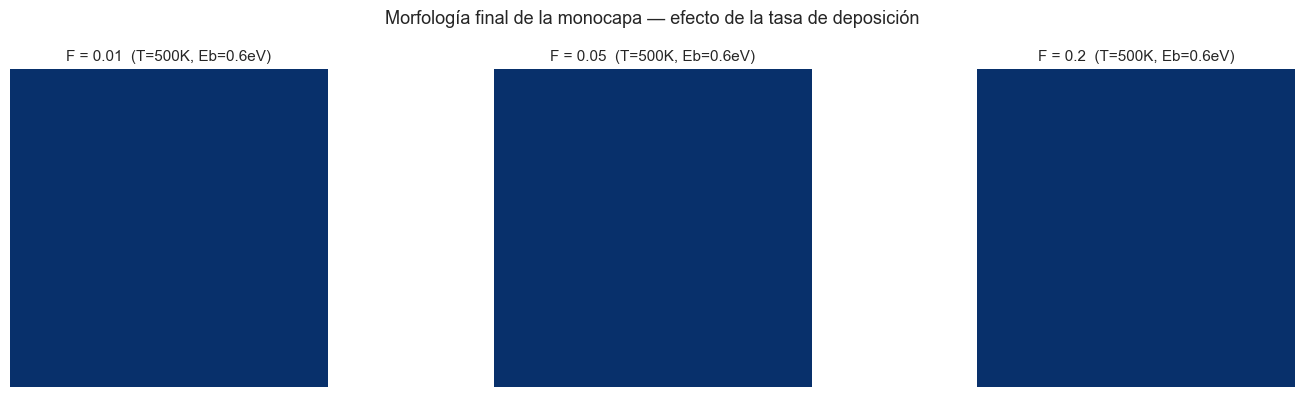

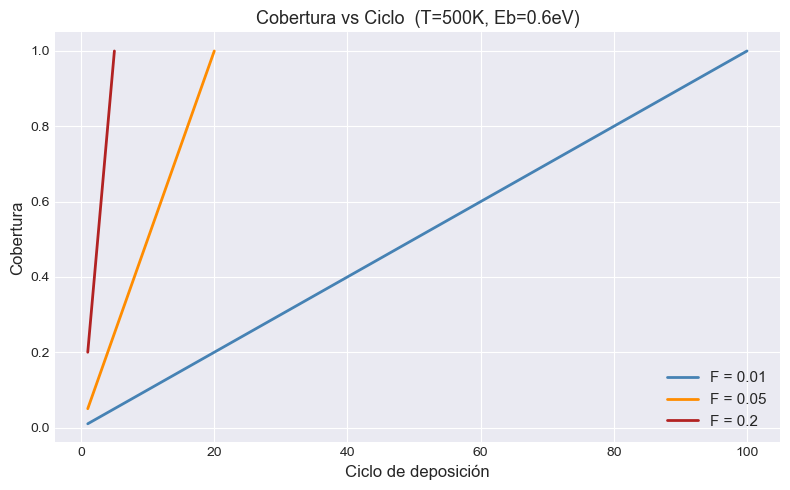

Gráficas guardadas: monocapa_tasa_deposicion.png, cobertura_vs_tasa.png


In [16]:
T_fixed = 500; Eb_fixed = 0.6
res_F = {}
for F in DEPOSITION_RATES:
    print(f'  F = {F} ...', end=' ', flush=True)
    res_F[F] = run_monolayer_growth(L=L, F=F, T_K=T_fixed, E_b=Eb_fixed, n_cycles=500)
    print(f'cobertura final = {res_F[F]["coverage"][-1]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_F = ['steelblue', 'darkorange', 'firebrick']
for ax, F, col in zip(axes, DEPOSITION_RATES, colors_F):
    ax.imshow(res_F[F]['grid'], cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'F = {F}  (T={T_fixed}K, Eb={Eb_fixed}eV)', fontsize=11)
    ax.axis('off')
plt.suptitle('Morfología final de la monocapa — efecto de la tasa de deposición', fontsize=13)
plt.tight_layout(); plt.savefig('monocapa_tasa_deposicion.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for F, col in zip(DEPOSITION_RATES, colors_F):
    cov = res_F[F]['coverage']
    ax.plot(np.arange(1, len(cov)+1), cov, color=col, lw=2, label=f'F = {F}')
ax.set_xlabel('Ciclo de deposición', fontsize=12); ax.set_ylabel('Cobertura', fontsize=12)
ax.set_title(f'Cobertura vs Ciclo  (T={T_fixed}K, Eb={Eb_fixed}eV)', fontsize=13)
ax.legend(fontsize=11); plt.tight_layout()
plt.savefig('cobertura_vs_tasa.png', dpi=150); plt.show()
print('Gráficas guardadas: monocapa_tasa_deposicion.png, cobertura_vs_tasa.png')

## 16. Efecto de la Temperatura del Sustrato

  T = 300 K ... cobertura final = 1.00
  T = 500 K ... cobertura final = 1.00
  T = 700 K ... cobertura final = 1.00


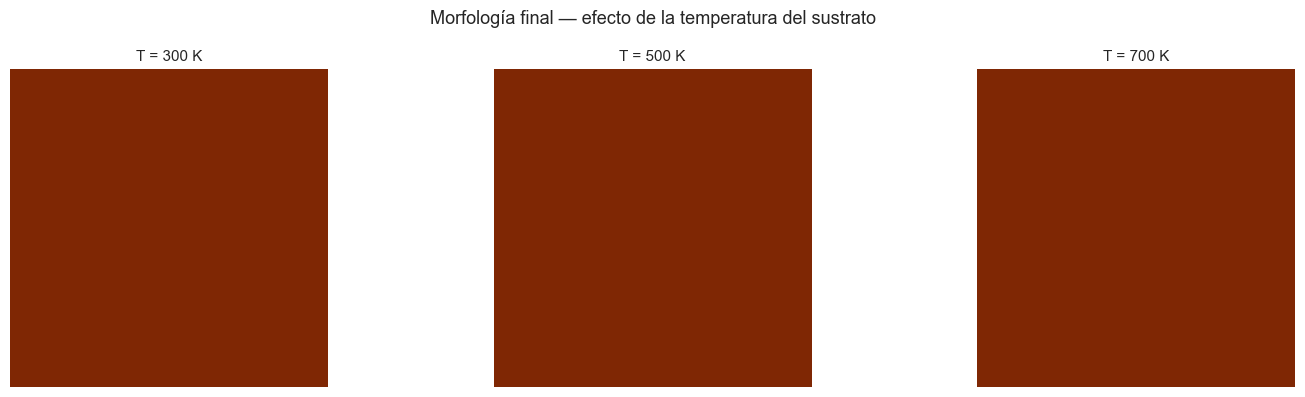

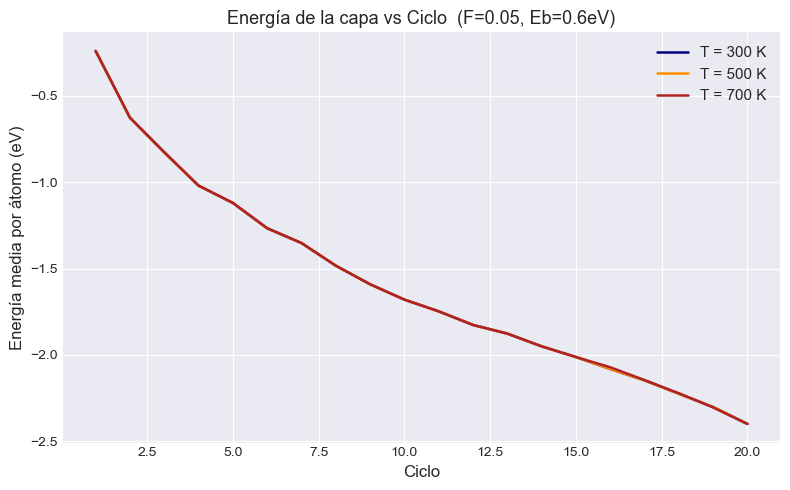

Gráficas guardadas: monocapa_temperatura.png, energia_monocapa_temperatura.png


In [17]:
F_fixed = 0.05
res_T = {}
for T in SUBSTRATE_TEMPS:
    print(f'  T = {T} K ...', end=' ', flush=True)
    res_T[T] = run_monolayer_growth(L=L, F=F_fixed, T_K=T, E_b=Eb_fixed, n_cycles=500)
    print(f'cobertura final = {res_T[T]["coverage"][-1]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_T = ['navy', 'darkorange', 'firebrick']
for ax, T, col in zip(axes, SUBSTRATE_TEMPS, colors_T):
    ax.imshow(res_T[T]['grid'], cmap='Oranges', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'T = {T} K', fontsize=11); ax.axis('off')
plt.suptitle('Morfología final — efecto de la temperatura del sustrato', fontsize=13)
plt.tight_layout(); plt.savefig('monocapa_temperatura.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for T, col in zip(SUBSTRATE_TEMPS, colors_T):
    eng = res_T[T]['energy']
    ax.plot(np.arange(1, len(eng)+1), eng, color=col, lw=1.8, label=f'T = {T} K')
ax.set_xlabel('Ciclo', fontsize=12); ax.set_ylabel('Energía media por átomo (eV)', fontsize=12)
ax.set_title(f'Energía de la capa vs Ciclo  (F={F_fixed}, Eb={Eb_fixed}eV)', fontsize=13)
ax.legend(fontsize=11); plt.tight_layout()
plt.savefig('energia_monocapa_temperatura.png', dpi=150); plt.show()
print('Gráficas guardadas: monocapa_temperatura.png, energia_monocapa_temperatura.png')

## 17. Efecto de la Energía de Enlace

  Eb = 0.3 eV ... cobertura final = 1.00
  Eb = 0.6 eV ... cobertura final = 1.00
  Eb = 1.0 eV ... cobertura final = 1.00


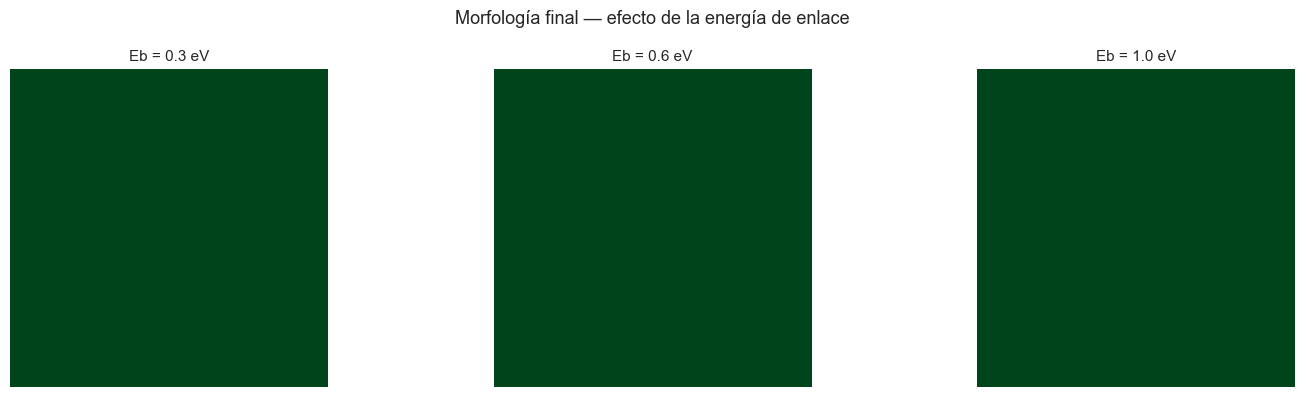

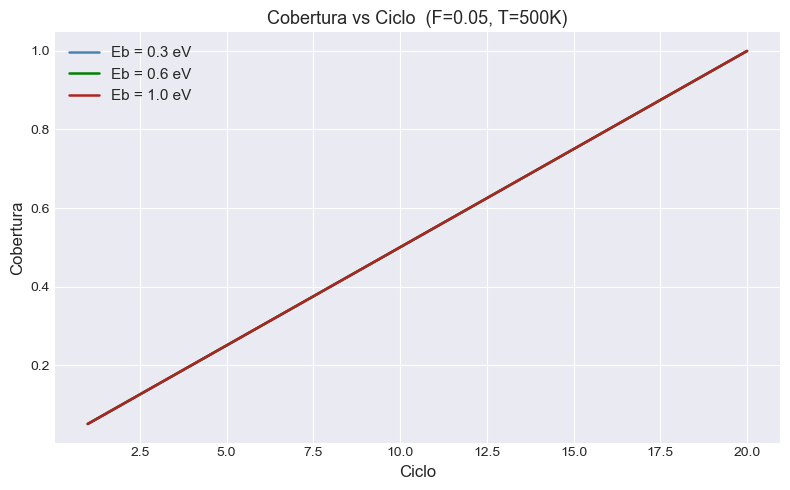

Gráficas guardadas: monocapa_energia_enlace.png, cobertura_vs_enlace.png


In [18]:
T_eb = 500
res_Eb = {}
for Eb in BINDING_ENERGIES:
    print(f'  Eb = {Eb} eV ...', end=' ', flush=True)
    res_Eb[Eb] = run_monolayer_growth(L=L, F=F_fixed, T_K=T_eb, E_b=Eb, n_cycles=500)
    print(f'cobertura final = {res_Eb[Eb]["coverage"][-1]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_Eb = ['steelblue', 'green', 'firebrick']
for ax, Eb, col in zip(axes, BINDING_ENERGIES, colors_Eb):
    ax.imshow(res_Eb[Eb]['grid'], cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'Eb = {Eb} eV', fontsize=11); ax.axis('off')
plt.suptitle('Morfología final — efecto de la energía de enlace', fontsize=13)
plt.tight_layout(); plt.savefig('monocapa_energia_enlace.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for Eb, col in zip(BINDING_ENERGIES, colors_Eb):
    cov = res_Eb[Eb]['coverage']
    ax.plot(np.arange(1, len(cov)+1), cov, color=col, lw=1.8, label=f'Eb = {Eb} eV')
ax.set_xlabel('Ciclo', fontsize=12); ax.set_ylabel('Cobertura', fontsize=12)
ax.set_title(f'Cobertura vs Ciclo  (F={F_fixed}, T={T_eb}K)', fontsize=13)
ax.legend(fontsize=11); plt.tight_layout()
plt.savefig('cobertura_vs_enlace.png', dpi=150); plt.show()
print('Gráficas guardadas: monocapa_energia_enlace.png, cobertura_vs_enlace.png')

## 18. Resumen comparativo — Tarea 3

In [19]:
# Tabla resumen: ciclos hasta cobertura ≥ 90 %
def cycles_to_coverage(cov_array, threshold=0.9):
    idx = np.argmax(cov_array >= threshold)
    return int(idx) if cov_array[idx] >= threshold else len(cov_array)

rows = []
for F in DEPOSITION_RATES:
    rows.append({'Parámetro': f'F = {F}', 'Tipo': 'Tasa dep.',
        'Cobertura final': f'{res_F[F]["coverage"][-1]:.3f}',
        'Ciclos hasta 90%': cycles_to_coverage(res_F[F]['coverage']),
        'E media final (eV/át.)': f'{res_F[F]["energy"][-1]:.3f}'})
for T in SUBSTRATE_TEMPS:
    rows.append({'Parámetro': f'T = {T} K', 'Tipo': 'Temperatura',
        'Cobertura final': f'{res_T[T]["coverage"][-1]:.3f}',
        'Ciclos hasta 90%': cycles_to_coverage(res_T[T]['coverage']),
        'E media final (eV/át.)': f'{res_T[T]["energy"][-1]:.3f}'})
for Eb in BINDING_ENERGIES:
    rows.append({'Parámetro': f'Eb = {Eb} eV', 'Tipo': 'Energía enlace',
        'Cobertura final': f'{res_Eb[Eb]["coverage"][-1]:.3f}',
        'Ciclos hasta 90%': cycles_to_coverage(res_Eb[Eb]['coverage']),
        'E media final (eV/át.)': f'{res_Eb[Eb]["energy"][-1]:.3f}'})

df_t3 = pd.DataFrame(rows)
print('=== Resumen Tarea 3: Nanofabricación — Crecimiento de Monocapa ===')
print(df_t3.to_string(index=False))
df_t3.to_csv('resumen_nanofabricacion.csv', index=False)
print('\nTabla guardada en resumen_nanofabricacion.csv')
print('Archivos generados:')
archivos = ['monocapa_tasa_deposicion.png', 'cobertura_vs_tasa.png',
            'monocapa_temperatura.png', 'energia_monocapa_temperatura.png',
            'monocapa_energia_enlace.png', 'cobertura_vs_enlace.png',
            'resumen_nanofabricacion.csv']
for f in archivos: print(f'  {f}')

=== Resumen Tarea 3: Nanofabricación — Crecimiento de Monocapa ===
  Parámetro           Tipo Cobertura final  Ciclos hasta 90% E media final (eV/át.)
   F = 0.01      Tasa dep.           1.000                89                 -2.400
   F = 0.05      Tasa dep.           1.000                17                 -2.400
    F = 0.2      Tasa dep.           1.000                 4                 -2.400
  T = 300 K    Temperatura           1.000                17                 -2.400
  T = 500 K    Temperatura           1.000                17                 -2.400
  T = 700 K    Temperatura           1.000                17                 -2.400
Eb = 0.3 eV Energía enlace           1.000                17                 -1.200
Eb = 0.6 eV Energía enlace           1.000                17                 -2.400
Eb = 1.0 eV Energía enlace           1.000                17                 -4.000

Tabla guardada en resumen_nanofabricacion.csv
Archivos generados:
  monocapa_tasa_deposicion